# Forest plot

Forest plots display point estimates with confidence intervals, commonly used in meta-analyses and clinical studies. Often these plots additionally include one or more side-tables.

## Forest plot 

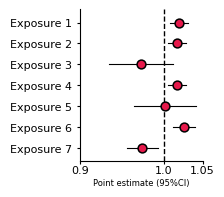

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

import plot_misc.example_data.examples as examples
import plot_misc.forest as forest
from plot_misc import utils as plm_utils

# Load data
data = examples.load_forest_preprocessed()
CMTOINCH = 1 / 2.54

# Creating a 3 column figure
fig, ax  = plt.subplots(figsize=(4 * CMTOINCH, 5 * CMTOINCH))

# Plot the  forest plot
trees = forest.ForestPlot(
    data=data,
    x_col="coef",
    lb_col="coef lower 95%",
    ub_col="coef upper 95%",
    g_col="Independent",
    ax=ax,
)
trees.plot(
    c_col="col",
    s_size_col=40,
    ci_lwd=0.8,
    ci_colour="black",
    span=False,
    reverse_y=True,
    kwargs_scatter_dict={"edgecolors": "black", "linewidth": 1.1, "zorder": 2},
    kwargs_plot_ci_dict={"zorder": 0},
)

# removing spines
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

# reference line
ax.axvline(0, linewidth=1, linestyle="--", c="black", zorder=0)

# setting axes limits and ticks
ax.set_xticks([])
ax.set_xticklabels([])
old_ylim = ax.get_ylim()
ax.set_ylim(old_ylim[0] + 0.5, old_ylim[1] - 0.5)
ax.set_xlim(np.log((0.90, 1.05)))
ax.tick_params(axis="y", labelsize=8, length=2.5)
ax.tick_params(
    axis="x", labelsize=8, length=2.5, pad=0.5
)

# Placing tick labels on log coordinates
plm_utils.utils.change_ticks(ax, ticks=[0.90, 1.00, 1.05], log=True)
_ = ax.set_xlabel("Point estimate (95%CI)", fontsize=6, labelpad=2)

## Forest plot with side table
Next we will make the same plot but now with the point estimates and confidence intervals strings appended as a side-table.

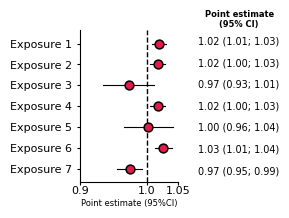

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

import plot_misc.example_data.examples as examples
import plot_misc.forest as forest
from plot_misc import utils as plm_utils

# Load data
data = examples.load_forest_preprocessed()
CMTOINCH = 1 / 2.54

# Creating a 2 column figure
fig = plt.figure(figsize=(6 * CMTOINCH, 5 * CMTOINCH))
gs = GridSpec(
    nrows=1,
    ncols=2,
     wspace=0.5,
    width_ratios=[
        8,
        4,
    ],
    figure=fig,
)
ax_main = fig.add_subplot(gs[(0, 0)])
ax_table1 = fig.add_subplot(gs[(0, 1)])

# Plot the main forest plot
trees = forest.ForestPlot(
    data=data,
    x_col="coef",
    lb_col="coef lower 95%",
    ub_col="coef upper 95%",
    g_col="Independent",
    ax=ax_main,
)
trees.plot(
    c_col="col",
    s_size_col=40,
    ci_lwd=0.8,
    ci_colour="black",
    span=False,
    reverse_y=True,
    kwargs_scatter_dict={"edgecolors": "black", "linewidth": 1.1, "zorder": 2},
    kwargs_plot_ci_dict={"zorder": 0},
)
# side table 
ax_table1.set_ylim(ax_main.get_ylim())
_ = forest.plot_table(
    data,
    annoteheader="Point estimate\n(95% CI)",
    string_col="string_estimates",
    halignment_text="center",
    halignment_header="center",
    size_text=7,
    size_header=6,
    negative_padding=2,
    ax=ax_table1,
)

# removing spines
ax_main.spines["right"].set_visible(False)
ax_main.spines["top"].set_visible(False)

# reference line
ax_main.axvline(0, linewidth=1, linestyle="--", c="black", zorder=0)

# setting axes limits and ticks
ax_main.set_xticks([])
ax_main.set_xticklabels([])
old_ylim = ax_main.get_ylim()
ax_main.set_ylim(old_ylim[0] + 0.5, old_ylim[1] - 0.5)
ax_main.set_xlim(np.log((0.90, 1.05)))
ax_main.tick_params(axis="y", labelsize=8, length=2.5)
ax_main.tick_params(axis="x", labelsize=8, length=2.5, pad=0.5)

# Placing tick labels on log coordinates
plm_utils.utils.change_ticks(ax_main, ticks=[0.90, 1.00, 1.05], log=True)
_ = ax_main.set_xlabel("Point estimate (95%CI)", fontsize=6, labelpad=2)